# SVRによる材料寿命（PredictedHours）の予測

`Material_Lifespan_Dataset_encoded_sklearn.csv` を使って、SVR（Support Vector Regression）で材料寿命 `PredictedHours` を予測します。

このCSVはカテゴリ変数がすでにOne-Hot Encodingされているため、ここでは数値特徴量を標準化し、SVRモデルを学習します。

## 0. 実行環境

前回作成した `uv` の仮想環境 `.venv` を使います。

必要パッケージは以下です。

```bash
uv --cache-dir .uv-cache pip install pandas numpy scikit-learn matplotlib seaborn ipykernel nbconvert
```

## 1. ライブラリの読み込み

In [1]:
# 数値計算を行うためのライブラリを読み込む
import numpy as np

# 表形式データを扱うためのライブラリを読み込む
import pandas as pd

# グラフを描画するためのライブラリを読み込む
import matplotlib.pyplot as plt

# 見やすい統計グラフを描くためのライブラリを読み込む
import seaborn as sns

# データを学習用とテスト用に分割する関数を読み込む
from sklearn.model_selection import train_test_split, GridSearchCV

# 前処理とモデルを1つの流れにまとめるPipelineを読み込む
from sklearn.pipeline import Pipeline

# 特徴量を平均0・標準偏差1にそろえる標準化を読み込む
from sklearn.preprocessing import StandardScaler

# SVRモデルを読み込む
from sklearn.svm import SVR

# 比較用の単純な基準モデルを読み込む
from sklearn.dummy import DummyRegressor

# 回帰モデルの性能を評価する指標を読み込む
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# seabornのグラフデザインを白背景のグリッド付きに設定する
sns.set_theme(style="whitegrid")

# 乱数を使う処理の結果を毎回同じにするため、乱数シードを固定する
RANDOM_STATE = 42

## 2. データの読み込みと基本確認

In [2]:
# 使用するCSVファイルのパスを指定する
DATA_PATH = "Material_Lifespan_Dataset_encoded_sklearn.csv"

# CSVファイルを読み込み、DataFrameとして保存する
df = pd.read_csv(DATA_PATH)

# データの先頭5行を表示し、列名や値の雰囲気を確認する
display(df.head())

# データの行数と列数を表示する
print("データ形状:", df.shape)

# 各列のデータ型を確認する
display(df.dtypes)

# 欠損値の数を列ごとに確認する
print("欠損値の数:")
display(df.isna().sum())

,PredictedHours,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,...,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
0,1461.797,12.836,3.803,6.515,47.005,65.450,16.618,16.510,0.938,10,...,1,0,0,1,0,1,0,0,1,0
1,1825.977,19.032,2.593,3.521,45.246,54.162,34.916,6.063,4.292,19,...,0,0,0,0,1,1,0,0,0,1
2,707.101,28.418,0.772,1.327,9.639,52.565,36.486,8.927,3.355,35,...,0,0,0,1,0,1,0,0,0,1
3,1086.370,9.084,1.990,2.201,20.009,56.665,23.436,17.040,2.827,0,...,1,0,1,0,0,0,1,1,0,0
4,1813.529,16.196,4.092,3.881,15.904,60.502,26.995,11.382,1.564,10,...,0,0,1,0,0,0,1,0,1,0


データ形状: (1000, 24)


PredictedHours                float64
CoolRate                      float64
QuenchDuration                float64
ForgeDuration                 float64
HeatProcessTime               float64
NickelComposition             float64
IronComposition               float64
CobaltComposition             float64
ChromiumComposition           float64
MinorDefects                    int64
MajorDefects                    int64
EdgeDefects                     int64
ComponentType_Blade             int64
ComponentType_Block             int64
ComponentType_Nozzle            int64
ComponentType_Valve             int64
StructureType_colGrain          int64
StructureType_equiGrain         int64
StructureType_singleGrain       int64
InitialPosition_Bottom          int64
InitialPosition_Top             int64
FormationMethod_Continuous      int64
FormationMethod_Die             int64
FormationMethod_Investment      int64
dtype: object

欠損値の数:


PredictedHours                0
CoolRate                      0
QuenchDuration                0
ForgeDuration                 0
HeatProcessTime               0
NickelComposition             0
IronComposition               0
CobaltComposition             0
ChromiumComposition           0
MinorDefects                  0
MajorDefects                  0
EdgeDefects                   0
ComponentType_Blade           0
ComponentType_Block           0
ComponentType_Nozzle          0
ComponentType_Valve           0
StructureType_colGrain        0
StructureType_equiGrain       0
StructureType_singleGrain     0
InitialPosition_Bottom        0
InitialPosition_Top           0
FormationMethod_Continuous    0
FormationMethod_Die           0
FormationMethod_Investment    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
PredictedHours,1000.0,1298.230182,340.891313,420.800,1040.89325,1267.7475,1561.21275,2155.117
CoolRate,1000.0,17.641305,7.497384,4.918,11.12075,17.7625,24.35025,30.585
QuenchDuration,1000.0,2.764455,1.317810,0.492,1.64100,2.7520,3.95675,5.079
ForgeDuration,1000.0,5.462845,2.604252,1.016,3.17225,5.4795,7.73875,10.089
HeatProcessTime,1000.0,30.190170,16.885729,1.024,16.21750,29.4225,45.10950,60.071
NickelComposition,1000.0,60.238923,5.831078,49.034,55.18900,60.5025,65.14075,71.106
IronComposition,1000.0,24.544107,7.366605,6.724,19.31775,24.6165,29.88100,43.636
CobaltComposition,1000.0,12.425300,4.331882,4.938,8.61000,12.5285,16.04650,20.265
ChromiumComposition,1000.0,2.767316,1.327204,0.506,1.59375,2.8625,3.92500,5.086
MinorDefects,1000.0,17.311000,12.268365,0.000,7.00000,18.0000,26.00000,61.000


/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


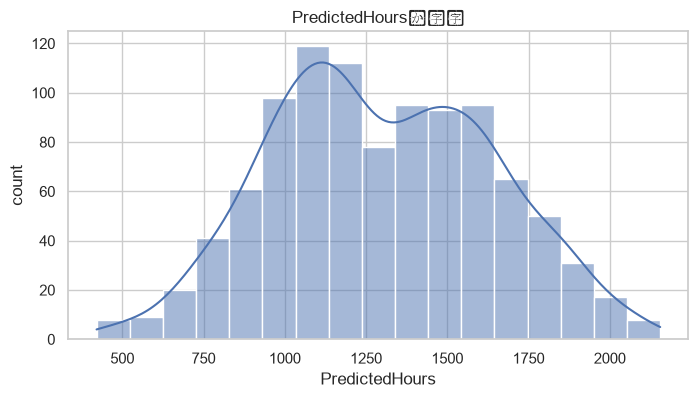

In [3]:
# 各列の基本統計量を確認する
# 平均、標準偏差、最小値、最大値などを見ることで、値のスケール感をつかむ
display(df.describe().T)

# 目的変数PredictedHoursの分布をヒストグラムで確認する
plt.figure(figsize=(8, 4))
sns.histplot(df["PredictedHours"], kde=True)
plt.title("PredictedHoursの分布")
plt.xlabel("PredictedHours")
plt.ylabel("count")
plt.show()

## 3. 説明変数Xと目的変数yを作る

目的変数は `PredictedHours` です。その他の列を説明変数として使います。

In [4]:
# ユーザー文ではPredictHoursとありますが、CSV内の実際の列名はPredictedHoursです
# そのため、この列を材料寿命の目的変数として使う
target_col = "PredictedHours"

# 目的変数以外の列をすべて説明変数として使う
feature_cols = [col for col in df.columns if col != target_col]

# 説明変数Xを作成する
X = df[feature_cols]

# 目的変数yを作成する
y = df[target_col]

# 使用する特徴量の数と名前を確認する
print("特徴量数:", len(feature_cols))
print("目的変数:", target_col)
display(pd.DataFrame({"feature": feature_cols}))

特徴量数: 23
目的変数: PredictedHours


,feature
0,CoolRate
1,QuenchDuration
2,ForgeDuration
3,HeatProcessTime
4,NickelComposition
5,IronComposition
6,CobaltComposition
7,ChromiumComposition
8,MinorDefects
9,MajorDefects


## 4. 学習データとテストデータに分割する

In [5]:
# データを学習用80%、テスト用20%に分割する
# random_stateを固定することで、毎回同じ分割結果になる
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# 分割後のデータサイズを確認する
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 23)
X_test : (200, 23)
y_train: (800,)
y_test : (200,)


## 5. 比較用の基準モデルを作る

SVRの性能を見る前に、平均値だけを予測する単純なモデルを作ります。SVRがこの基準モデルより良ければ、特徴量から寿命を予測できていると判断しやすくなります。

In [6]:
# 平均値だけを予測する基準モデルを作る
baseline_model = DummyRegressor(strategy="mean")

# 学習データの目的変数y_trainの平均を学習する
baseline_model.fit(X_train, y_train)

# テストデータに対して予測する
baseline_pred = baseline_model.predict(X_test)

# 基準モデルの評価指標を計算する
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

# 基準モデルの結果を表示する
print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2  :", baseline_r2)

Baseline MAE : 266.0621699625
Baseline RMSE: 322.2038255831067
Baseline R2  : -0.00281099165408194


## 6. SVRモデルを作る

SVRは特徴量のスケールに敏感です。そのため `StandardScaler` で標準化してから `SVR` を学習します。

ここでは `GridSearchCV` を使って、`C`、`epsilon`、`gamma` を探索します。

In [7]:
# Pipelineで「標準化 -> SVR」を1つの流れとして定義する
svr_pipeline = Pipeline([
    # すべての特徴量を平均0・標準偏差1に標準化する
    ("scaler", StandardScaler()),

    # SVRモデルを定義する
    # kernelは非線形関係を扱いやすいrbfを使う
    ("svr", SVR(kernel="rbf")),
])

# 探索するパラメータ候補を指定する
# C: 誤差をどれくらい厳しく罰するか
# epsilon: どこまでの誤差を無視するか
# gamma: RBFカーネルで1つの点の影響範囲をどうするか
param_grid = {
    "svr__C": [1, 10, 100, 300],
    "svr__epsilon": [1, 5, 10, 20],
    "svr__gamma": ["scale", 0.01, 0.05, 0.1],
}

# GridSearchCVで交差検証を行い、最も良いパラメータを探す
# n_jobs=1にして、並列処理が制限される環境でも安定して動くようにする
# scoring="neg_root_mean_squared_error"は、RMSEが小さいモデルを選ぶための指定
grid_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=1,
)

# 学習データを使って、パラメータ探索とモデル学習を実行する
grid_search.fit(X_train, y_train)

# 最も良かったパラメータを表示する
print("Best parameters:")
display(grid_search.best_params_)

# 交差検証での最良RMSEを表示する
# GridSearchCVでは負のRMSEで保存されるので、-を付けて正のRMSEに戻す
print("Best CV RMSE:", -grid_search.best_score_)

Best parameters:


{'svr__C': 300, 'svr__epsilon': 20, 'svr__gamma': 'scale'}

Best CV RMSE: 216.94629494774568


## 7. テストデータで予測し、性能を評価する

In [8]:
# 最も良かったSVRモデルを取り出す
best_svr_model = grid_search.best_estimator_

# テストデータに対して材料寿命を予測する
y_pred = best_svr_model.predict(X_test)

# MAEを計算する
# 予測値と実測値の差の絶対値の平均。小さいほど良い
mae = mean_absolute_error(y_test, y_pred)

# RMSEを計算する
# 大きな誤差を重めに見る指標。小さいほど良い
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2スコアを計算する
# 1に近いほど予測がよくできている
r2 = r2_score(y_test, y_pred)

# 評価結果を表にまとめる
results = pd.DataFrame([
    {
        "model": "Baseline(mean)",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2,
    },
    {
        "model": "SVR(rbf)",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    },
])

# 評価結果を表示する
display(results)

,model,MAE,RMSE,R2
0,Baseline(mean),266.06217,322.203826,-0.002811
1,SVR(rbf),150.26616,191.972611,0.644011


## 8. 予測値と実測値を可視化する

/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv

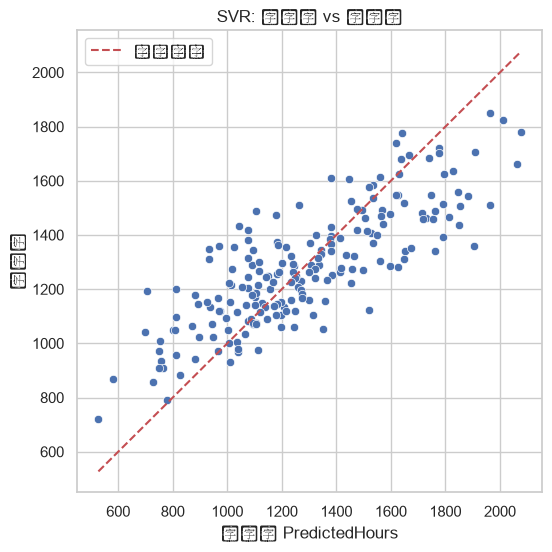

In [9]:
# 予測値と実測値を比較する散布図の描画領域を作る
plt.figure(figsize=(6, 6))

# 横軸に実測値、縦軸に予測値を置いて散布図を描く
sns.scatterplot(x=y_test, y=y_pred)

# 完全一致線を引くため、実測値と予測値を含めた最小値を求める
min_val = min(y_test.min(), y_pred.min())

# 完全一致線を引くため、実測値と予測値を含めた最大値を求める
max_val = max(y_test.max(), y_pred.max())

# 予測値と実測値が完全に一致する基準線を赤い破線で描く
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="完全一致")

# 横軸ラベルを設定する
plt.xlabel("実測値 PredictedHours")

# 縦軸ラベルを設定する
plt.ylabel("予測値")

# グラフタイトルを設定する
plt.title("SVR: 予測値 vs 実測値")

# 凡例を表示する
plt.legend()

# グラフを表示する
plt.show()

/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv

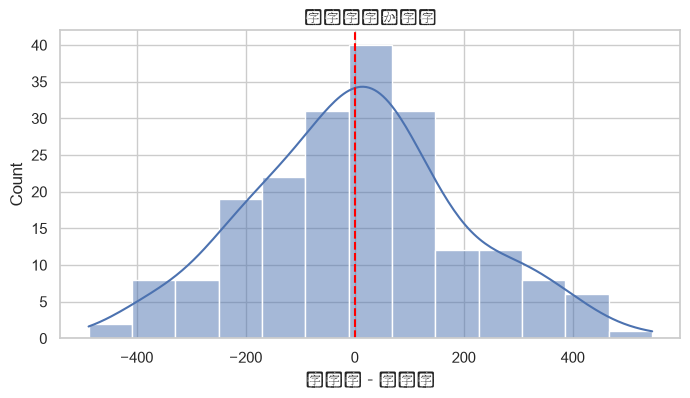

In [10]:
# 予測誤差を計算する
# 正の値なら予測値が実測値より大きく、負の値なら予測値が実測値より小さい
residuals = y_test - y_pred

# 誤差分布を確認するための描画領域を作る
plt.figure(figsize=(8, 4))

# 予測誤差のヒストグラムを描く
sns.histplot(residuals, kde=True)

# 誤差0の位置に縦線を引く
plt.axvline(0, color="red", linestyle="--")

# グラフタイトルを設定する
plt.title("予測誤差の分布")

# 横軸ラベルを設定する
plt.xlabel("実測値 - 予測値")

# グラフを表示する
plt.show()

## 9. 重要そうな特徴量を確認する

,correlation_with_PredictedHours
NickelComposition,0.311742
IronComposition,-0.245079
ComponentType_Block,0.166935
FormationMethod_Continuous,0.122780
ComponentType_Valve,-0.121526
HeatProcessTime,-0.106665
MinorDefects,0.103787
QuenchDuration,0.100956
FormationMethod_Investment,-0.083508
ChromiumComposition,0.076241


/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv

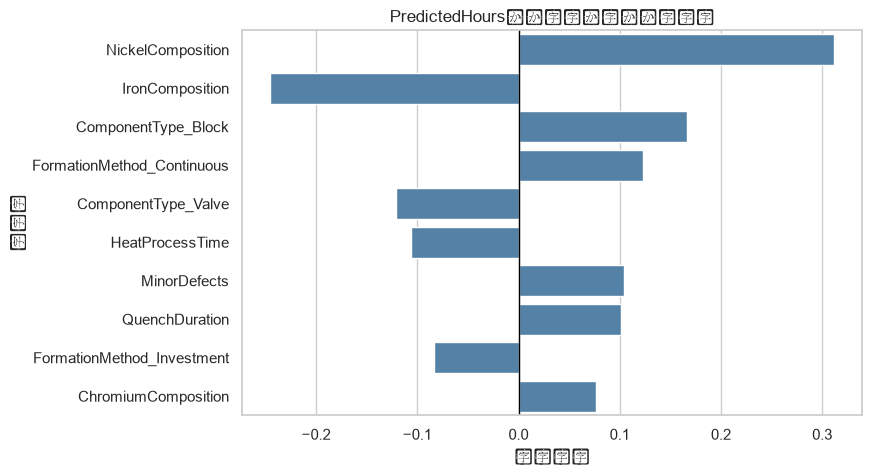

In [11]:
# SVRは線形回帰のように係数を直接解釈しにくいモデルです
# そこで、目的変数PredictedHoursとの相関係数を見て、関係が強そうな特徴量を確認する
corr_with_target = (
    df.corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

# 相関の絶対値が大きい上位10個の特徴量を表示する
display(corr_with_target.head(10).to_frame("correlation_with_PredictedHours"))

# 上位10特徴量の相関係数を棒グラフで表示する
top_corr = corr_with_target.head(10).reset_index()
top_corr.columns = ["feature", "correlation"]

plt.figure(figsize=(8, 5))
sns.barplot(data=top_corr, x="correlation", y="feature", color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("PredictedHoursとの相関が大きい特徴量")
plt.xlabel("相関係数")
plt.ylabel("特徴量")
plt.show()

## 10. まとめ

In [12]:
# R2が高かったモデルを確認する
best_result = results.sort_values("R2", ascending=False).iloc[0]

# 最終結果を表示する
print(f"最もR2が高かったモデル: {best_result['model']}")
print(f"MAE : {best_result['MAE']:.3f}")
print(f"RMSE: {best_result['RMSE']:.3f}")
print(f"R2  : {best_result['R2']:.3f}")

# 今回行った処理のポイントを表示する
print("\n今回のポイント:")
print("- PredictedHoursを目的変数として材料寿命を予測した")
print("- 特徴量はすでにエンコード済みなので、そのまま数値特徴量として使った")
print("- SVRはスケールに敏感なのでStandardScalerで標準化した")
print("- GridSearchCVでC、epsilon、gammaを探索した")
print("- テストデータでMAE、RMSE、R2を確認した")

最もR2が高かったモデル: SVR(rbf)
MAE : 150.266
RMSE: 191.973
R2  : 0.644

今回のポイント:
- PredictedHoursを目的変数として材料寿命を予測した
- 特徴量はすでにエンコード済みなので、そのまま数値特徴量として使った
- SVRはスケールに敏感なのでStandardScalerで標準化した
- GridSearchCVでC、epsilon、gammaを探索した
- テストデータでMAE、RMSE、R2を確認した
